In [ ]:
import snowflake.snowpark as snowpark
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import StringType, StructType, StructField, TimestampType
import pandas as pd
import numpy as np
from datetime import date
from datetime import datetime
import re
from snowflake.snowpark import Session
from snowflake.snowpark.functions import sum, col, coalesce
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from datetime import timedelta
from thefuzz import fuzz
from dotenv import load_dotenv
import os

load_dotenv()

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

In [2]:
#Snowpark Connection Configuration
#INGESTED
connection_parameters = {
    "account": "yva20138.us-west-2.privatelink",
    "user": "ben.pharris@dish.com",
    "authenticator": "externalbrowser",
    "insecure_mode":True,
}

new_session = snowpark.Session.builder.configs(connection_parameters).create()

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://dish.okta.com/app/snowflake/exk9ewak82R5btDoW2p7/sso/saml?SAMLRequest=pZJPc9owEMW%2Fikc925JMaYwGkyEQWmbSloJDJrkJW4BiW3K1MgY%2BfWX%2BdNJDculNI73V7%2B2%2B7d%2Fuy8LbCQNSqxjRgCBPqFRnUm1i9JhM%2FAh5YLnKeKGViNFBALod9IGXRcWGtd2qufhdC7Ce%2B0gBax9iVBvFNAcJTPFSALMpWwy%2FP7AwIIwDCGMdDl1KMpCOtbW2Yhg3TRM0nUCbDQ4JIZj0sFO1kk%2FoDaL6mFEZbXWqi2vJ3vX0DoJi8rlFOIUjzC6Fd1KdR%2FARZXUWAfuWJDN%2F9nORIG947W6kFdSlMAthdjIVj%2FOHswFwDp6Xw5DQThTU4Ddudn4YVEbuuBWFVHkASjfrguci1WVVW4cI3AmvRYYLvZFucNNxjKpcZndqsdq%2BPM%2Bf6pVKctAR%2BbW8%2F7ruHr%2B8Lg73r6OUrhK%2BnR4nR0iRt7zGHLYxTwFqMVVtuNZdkbDrk8inNKE9RjuMhsFNL3pB3tgZlIrbU%2BW1g0zCNtC55SdnvKrwX9NY7POeaHgehfPuyo71U1jdYACN2%2BDQeXfYiW4G%2FzWRPn771WUnf7iYpuOZLmR68CbalNy%2BnyIN6OlGZv76JGWi5LIYZpkRAC7NotDNyAjnI0bW1ALhwZn67%2

In [3]:
# --- OpenSignal Read-in 
#INGESTED
session = Session.builder.configs(connection_parameters).create()

source_table = "DISH_RETAIL_DL.MARS.DE0008_OPENSIGNAL_WMS_METRICS"
date_col = "DATE"

sql_query = f"""
    SELECT *
    FROM {source_table}
    WHERE LEFT({date_col}, 4) > '2023'
"""
sp = session.sql(sql_query)
opensignal_df = sp.to_pandas()
opensignal_df['DATE'] = pd.to_datetime(opensignal_df['DATE'])
opensignal_df['MONTHLY_VALUE'] = pd.to_numeric(
    opensignal_df['MONTHLY_VALUE'],
    errors='coerce'
)

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://dish.okta.com/app/snowflake/exk9ewak82R5btDoW2p7/sso/saml?SAMLRequest=pZJbc9owEIX%2Fikd9tuRLMyEaTMYJZeIODRRM0vZN2AI0tiVFK2PSX1%2BZSyd9SF76ppHO6ju7Z4e3h6b29tyAUDJBIQ6Qx2WhSiG3CVrlE3%2BAPLBMlqxWkifolQO6HQ2BNbWmaWt3csFfWg7Wcx9JoP1DglojqWIggErWcKC2oMv025RGOKAMgBvrcOhcUoJwrJ21mhLSdR3uYqzMlkRBEJDghjhVL%2FmE3iD0xwxtlFWFqi8lB9fTO4iQBJ97hFM4wvxceCfkaQQfUdYnEdCHPJ%2F789kyR1566e5eSWgbbpbc7EXBV4vpyQA4Bz%2Bf0igI4wFuwe%2Fc7PwIayP2zPJayAqDVN2mZhUvVKNb6xDYnciGl6RWW%2BEGl40TpCtRTheZ1HcFTw%2FT%2FMd60a3iw%2Bz52j5MvtsvX%2FczlU%2Bmu5dMrn%2BviwJ5T5eYoz7mDKDlmezDte4qiK78YOCHYR7e0DCmcYyjKPqFvLEzKCSzx8pLB6WAHVaVZUdnTGvy1zThh%2BqGd6waRIurtR2r50hfEwBF%2BuDQaXfokW5G%2FzWRIXn71XknH11M2XiualG8ehNlGmbfTzHE4fFGlP7mKKW8YaJOy9JwAJdmXavu3nDnI0HWtByR0Yn67%2FKP%2FgA%3D&

In [4]:
#--- Opensignal Data Integrity Check  

print(opensignal_df['CARRIER'].unique())
print(opensignal_df.columns)
print(opensignal_df['METRIC'].unique())
print(opensignal_df['SEGMENT'].unique())

del(sp, source_table, new_session, date_col, sql_query)

['AT&T' 'Boost Mobile' 'Cox Mobile' 'Cricket Wireless' 'MetroPCS'
 'Optimum Mobile' 'Other' 'Spectrum Mobile' 'T-Mobile' 'Tracfone'
 'U.S. Cellular' 'Verizon Wireless' 'Xfinity Mobile']
Index(['VALUE', 'DATALAKE_SOURCE_FILENAME', 'CARRIER', 'GEO_DMA', 'SEGMENT',
       'METRIC', 'DATE', 'MONTHLY_VALUE', 'LOAD_DATE'],
      dtype='object')
['Subscribers' 'Market Share' 'Gross Adds' 'Share of Gross Adds'
 'Gross Losses' 'Share of Gross Losses' 'Churn' 'Net Adds']
['Overall (Prepaid and Postpaid)' 'Postpaid' 'Prepaid']


In [5]:
# --- Converting OpenSignal to Population by Market

subscribers_df = opensignal_df[
    (opensignal_df['METRIC'] == 'Subscribers') &
    (opensignal_df['SEGMENT'] != 'Overall (Prepaid and Postpaid)')
].copy()

subscribers_df = subscribers_df.groupby(['DATE', 'GEO_DMA'])['MONTHLY_VALUE'].sum().reset_index()

subscribers_df = subscribers_df.rename(columns={'MONTHLY_VALUE': 'TOTAL_SUBSCRIBERS'})

In [6]:
# --- OpenSignal Integrity Checks

assert not subscribers_df.duplicated(subset=['DATE', 'GEO_DMA']).any(), "Error: Duplicate DATE-DMA pairs found!"

# If the assertion passes, this message will print
print("✅ Integrity Check Passed: No duplicate DATE-DMA pairs exist.")

# ---  Population Integrity Check: no missing date-market pairs
dma_counts_per_date = subscribers_df.groupby('DATE')['GEO_DMA'].nunique()

assert dma_counts_per_date.min() == dma_counts_per_date.max(), \
    "Error: The number of DMAs is inconsistent across dates."

# If the check passes, print a success message
print(f"✅ Integrity Check Passed: All dates have the same number of DMAs ({dma_counts_per_date.iloc[0]}).")


del(dma_counts_per_date)

✅ Integrity Check Passed: No duplicate DATE-DMA pairs exist.
✅ Integrity Check Passed: All dates have the same number of DMAs (211).


In [7]:
# --- Marketing Spend (Viju)
#INGESTED

session = Session.builder.configs(connection_parameters).create()

viju = session.table('sbx.sbx_boostcbm.an0002_platform_budgets').to_pandas()
viju['DATE'] = pd.to_datetime(viju['DATE'])

viju.describe()

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://dish.okta.com/app/snowflake/exk9ewak82R5btDoW2p7/sso/saml?SAMLRequest=pZJPc9owEMW%2Fikc927IckoAGyBBoEjKEMOCkQ2%2FCEqCxLLlaGUM%2FfWX%2BdNJDculNI73V7%2B2%2B7d7tCxXshAVpdA%2BRKEaB0JnhUm966C19CNsoAMc0Z8po0UMHAeiu3wVWqJIOKrfVc%2FGrEuAC%2F5EG2jz0UGU1NQwkUM0KAdRldDF4mdAkiikDENZ5HDqXcJCetXWupBjXdR3VV5GxG5zEcYzjDvaqRvINfUCUXzNKa5zJjLqU7H1PnyAIjlsNwis8YXYuvJf6NIKvKKuTCOhTms7C2esiRcHg0t3QaKgKYRfC7mQm3uaTkwHwDpbvgyQmV%2B2ogrD2swuTqLRyx5xQUucRaFOvFctFZoqych4R%2BRNeC46V2Ug%2FuPGoh8pc8kexPUyf9q83z6vZPOX3Um3gNyfL1vK7fYbJlCeroXyc305usgwF75eYkybmMUAlxroJ1%2FmrOLkO43ZISEo6lLQoSSKStH6iYOQNSs3csfLSAZewjUzu2NEZK0v81zQW%2B7wjapa3k%2Fn1yo3Mj6S8xQAGN8Gh0%2B7QI932%2F2siXfzxq%2FNOTn1M49HMKJkdggdjC%2BY%2BT5FE5Hgjebg%2BSqkomFQDzq0A8GkqZeqhFd5HDzlbCYT7J%2Bq%2Fy9%

,DATE,ACTUAL_SPEND,FORECAST_SPEND,PROJECTED_SPEND,PLANNED_SPEND,IMPRESSIONS,CLICKS,ENGAGED_SESSIONS,ACTUAL_GA,ACTUAL_INVOL_DEACT,ACTUAL_VOL_DEACT,ACTUAL_REACT,ACTUAL_NETADD,FORECAST_GA,PLAN_GA,FORECAST_DA,PLAN_DA,FORECAST_NA,PLAN_NA,ALT_ACTUAL_GA,ALT_ACTUAL_VOL_DEACT,ALT_ACTUAL_INVOL_DEACT,ALT_ACTUAL_REACT,ALT_ACTUAL_NETADD
count,133407,133407.000000,133407.000000,1.006020e+05,1.334070e+05,1.334070e+05,133407.000000,133407.000000,85023.000000,85023.000000,85023.000000,85023.000000,85023.000000,133407.000000,133407.000000,133407.000000,133407.000000,133407.000000,133407.000000,78840.000000,78840.000000,78840.000000,78840.000000,78840.000000
mean,2025-04-01 00:00:00.000000256,3113.204455,3250.755335,1.240682e+05,1.255048e+05,2.326834e+06,12938.952844,3229.304932,909.645602,624.143220,330.720229,138.649413,93.431566,840.282757,881.070330,840.282757,881.070330,840.282757,881.070330,977.748973,77.414041,266.133219,51.226027,685.427740
min,2024-07-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-4.000000,0.000000,0.000000,0.000000,-7364.000000,-254.837819,0.000000,-254.837819,0.000000,-254.837819,0.000000,-1.000000,0.000000,0.000000,0.000000,-1.000000
25%,2024-11-15 00:00:00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,26.000000,7.000000,5.000000,1.000000,-8.000000,8.000000,25.375799,8.000000,25.375799,8.000000,25.375799,22.000000,1.000000,1.000000,0.000000,17.000000
50%,2025-04-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,78.000000,27.000000,20.000000,9.000000,19.000000,49.000000,75.247030,49.000000,75.247030,49.000000,75.247030,87.500000,4.000000,9.000000,3.000000,64.000000
75%,2025-08-16 00:00:00,11.677100,27.720000,4.058564e+03,5.312505e+03,5.960700e+04,0.000000,0.000000,829.000000,627.000000,301.000000,117.000000,94.000000,794.000000,770.691915,794.000000,770.691915,794.000000,770.691915,1186.250000,38.000000,328.000000,48.000000,772.250000
max,2025-12-31 00:00:00,762752.874000,553680.000000,1.191483e+07,1.019388e+07,9.154473e+07,520156.000000,126622.000000,11968.000000,9696.000000,3364.000000,1794.000000,6593.000000,12034.000000,11926.899796,12034.000000,11926.899796,12034.000000,11926.899796,11915.000000,1289.000000,4069.000000,931.000000,9710.000000
std,NaN,22712.772191,22160.501697,7.425423e+05,6.971011e+05,8.371061e+06,47441.831318,12008.554372,1636.258540,1194.167045,663.031102,278.454037,618.841401,1587.270067,1674.461026,1587.270067,1674.461026,1587.270067,1674.461026,1680.196736,172.076280,540.857610,106.316630,1214.515163


In [8]:
# --- Viju Marketing Spend to Long Format

national_df = viju.pivot_table(
    index='DATE',
    columns='PLATFORM',
    values='ACTUAL_SPEND',
    aggfunc='sum'  # <-- This is the key change
)

national_df = national_df.reset_index().fillna(0)
national_df['DATE'] = pd.to_datetime(national_df['DATE'])


Index(['DATE', 'Affiliate', 'Amazon',
       'Disney+/Hulu/ESPN - Ovative Pass Through',
       'DraftKings - Ovative Pass Through', 'GSTV - Ovative Pass Through',
       'Google', 'Influencer', 'Kargo - Ovative Pass Through', 'Last Mile',
       'Local Google', 'Local Marketing', 'Local Meta',
       'MMG - Ovative Pass Through', 'Meta', 'Microsoft', 'National Retail',
       'Other', 'Reddit', 'Snapchat', 'TheVolume - Ovative Pass Through',
       'TikTok', 'Univision', 'Vevo - Ovative Pass Through', 'Yahoo',
       'YouTube', 'Zeta', 'iHeart'],
      dtype='object', name='PLATFORM')


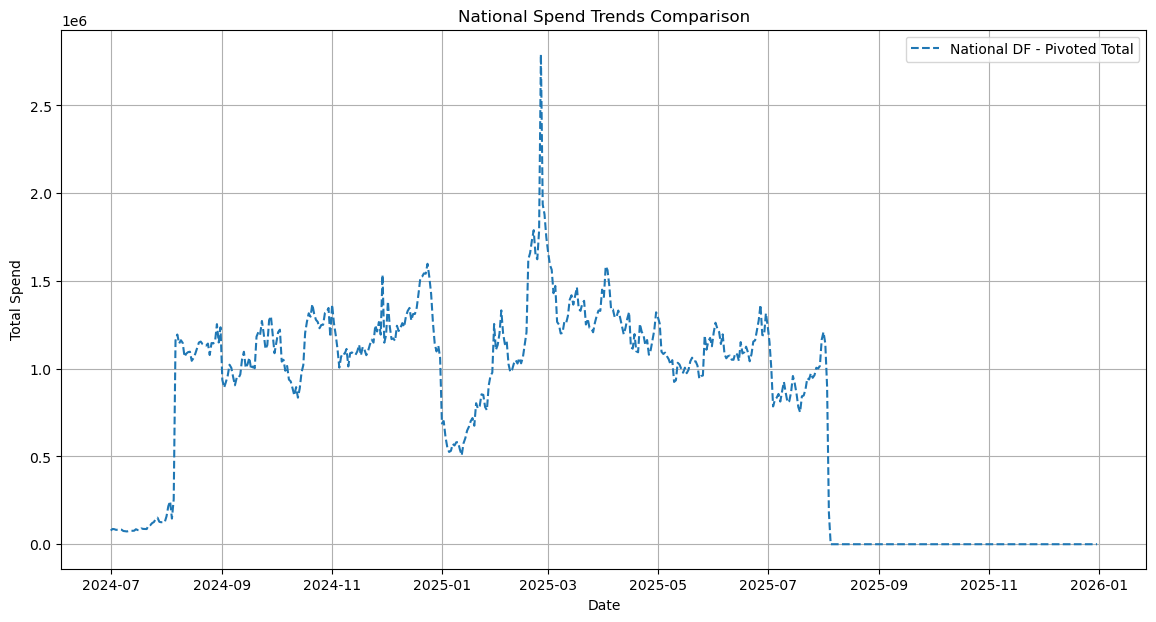

In [9]:
# --- Diagnostics

print(national_df.columns)

spend_columns = national_df.columns.drop('DATE', 'Local Marketing')
national_df['TOTAL'] = national_df[spend_columns].sum(axis=1)

plt.figure(figsize=(14, 7))


# Plot the new total spend from the pivoted national_df_2
plt.plot(national_df['DATE'], national_df['TOTAL'], label='National DF - Pivoted Total', linestyle='--')

# Formatting the plot
plt.title('National Spend Trends Comparison')
plt.xlabel('Date')
plt.ylabel('Total Spend')
plt.legend()
plt.grid(True)
plt.show()

del(viju)
del(spend_columns)

## Building Local Marketing Data
### OOH, Radio, Events data pulled from individual tables and merged

In [10]:
# --- Local MKTG Reverse Engineering

session = Session.builder.configs(connection_parameters).create()

print("--- Creating Lazy DataFrames for Each Marketing Tactic ---")

# --- 1. Out-of-Home (OOH) Spend ---
# This view contains total spend for each OOH campaign.
ooh_df = session.table("SBX.SBX_BOOSTCBM.AL0001_OOH_VW")
print("\n✅ Created lazy DataFrame for OOH. Showing first 5 rows:")
ooh_df.show(5)

# --- 2. Radio Spend ---
# This view contains total spend for each Radio campaign.
radio_df = session.table("SBX.SBX_BOOSTCBM.AL0001_RADIO_VW")
print("\n✅ Created lazy DataFrame for Radio. Showing first 5 rows:")
radio_df.show(5)

# --- 3. Digital Spend ---
# This view contains total spend for each Digital campaign.
digital_df = session.table("SBX.SBX_BOOSTCBM.AL0001_DIGITAL_VW")
print("\n✅ Created lazy DataFrame for Digital. Showing first 5 rows:")
digital_df.show(5)

# --- 4. Festivals & Sponsorships Spend ---
# This view contains total spend for each event.
festivals_df = session.table("SBX.SBX_BOOSTCBM.AL0001_FESTIVALS_SPONSORSHIPS_VW")
print("\n✅ Created lazy DataFrame for Festivals & Sponsorships. Showing first 5 rows:")
festivals_df.show(5)

# --- 5. Other Spend ---
# This view contains spend for other miscellaneous campaigns.
other_df = session.table("SBX.SBX_BOOSTCBM.AL0001_OTHER_VW")
print("\n✅ Created lazy DataFrame for Other Spend. Showing first 5 rows:")
other_df.show(5)

market_spend_source_df = session.table("sbx.sbx_boostcbm.AL0001_DAILY_MARKET_SPEND_VW")


 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://dish.okta.com/app/snowflake/exk9ewak82R5btDoW2p7/sso/saml?SAMLRequest=pZJbT%2BMwEIX%2FSuR9TpyEIlqrKQqtunTFQtXbLry5ybS1ktjG4zTl36%2FTywoe4IU3yz7j78yc6d8eqtLbg0GhZEKiICQeyEzlQm4TslyM%2FS7x0HKZ81JJSMgbILkd9JFXpWZpbXdyBq81oPXcRxJZ%2B5CQ2kimOApkkleAzGZsnv5%2BYHEQMo4IxjocOZfkKBxrZ61mlDZNEzRXgTJbGodhSMMedapW8oO8Q%2BivGdooqzJVXkoOrqdPEBENOy3CKRxhei68E%2FI0gq8o65MI2f1iMfWnT%2FMF8dJLd0Mlsa7AzMHsRQbL2cPJADoHz6s0DqOrblCj37jZ%2BXGgjdhzC6WQRYBSNZuSF5CpStfWIQJ3ohvIaam2wg1uMkqILkQe3%2FFiC0uFncPrfjh8fF5z%2FXPZuU9hNa3mk5dxMc5%2F%2FV2mM40Z8VaXmOM25gliDRPZhmvdVRhf%2B2HXj6JF1GNRh0XdII5vXog3cgaF5PZYeekgF7gLVGH50RnXmv43TeFQ9KDhRTeeXa%2FtSP2J9Q1FVLQNjpx2hx3pZvCtifTp%2B6%2FOO%2FnoYpqMpqoU2Zs3Vqbi9vMUoyA63ojc3xylDCouyjTPDSC6NMtSNUMDzkdCrKmB0MGJ%2BnH5B%2F8A&Re

In [11]:
# --- Local MKTG - convert to Pandas and merge function definition

def get_tactic_pandas_df(snowpark_df, tactic_name):
    """
    Selects key columns from a Snowpark DataFrame, fills TOTAL_BUDGET_SPENT
    using fallback logic (INVOICE_AMOUNT_RECEIVED, TOTAL_BUDGET_ALLOCATED),
    adds a tactic label, and converts it to a pandas DataFrame.
    """
    return (
        snowpark_df.select(
            col("MARKET"),
            col("START_DATE"),
            col("END_DATE"),
            coalesce(
                col("TOTAL_BUDGET_SPENT"),
                col("INVOICE_AMOUNT_RECEIVED"),
                col("TOTAL_BUDGET_ALLOCATED")
            ).alias("TOTAL_BUDGET_SPENT")
        )
        .to_pandas()
        .assign(TACTIC=tactic_name)
    )

In [12]:
# --- Converting Snowpark DataFrames to Pandas

print("--- Converting Snowpark DataFrames to Pandas ---")

# Convert each Snowpark DataFrame to a pandas DataFrame
pd_ooh_df = get_tactic_pandas_df(ooh_df, "OOH")
pd_radio_df = get_tactic_pandas_df(radio_df, "RADIO")
pd_digital_df = get_tactic_pandas_df(digital_df, "DIGITAL")
pd_festivals_df = get_tactic_pandas_df(festivals_df, "FESTIVALS")
pd_other_df = get_tactic_pandas_df(other_df, "OTHER")

--- Converting Snowpark DataFrames to Pandas ---


In [13]:
# --- Environment Cleanup
vars_to_delete = ['date_col', 'digital_df', 'ooh_df', 'radio_df', 'festivals_df', 'new_session', 'opensignal_df',
                  'other_df', 'source_table', 'sp', 'sql_query']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]

del(vars_to_delete)

In [14]:
# --- Special Logic For DTR Events
# DTR spend is tracked at the store level, so we pull from the daily store spend

dtr_df = session.table("sbx.sbx_boostcbm.AL0001_DAILY_STORE_SPEND_VW")
print("\n✅ Created lazy DataFrame for DTR Events. Showing first 5 rows:")
dtr_df.show(5)

def get_dtr_pandas_df(snowpark_df, tactic_name):
    """
    Selects key columns from a Snowpark DataFrame, adds a tactic label,
    and converts it to a pandas DataFrame.
    """
    return snowpark_df.select(
        col("DDM_ID"),
        col("START_DATE"),
        col("END_DATE"),
        col("DAILY_SPEND_ACTUAL")
    ).to_pandas().assign(TACTIC=tactic_name)


pd_dtr_df = get_dtr_pandas_df(dtr_df, "DTR")


✅ Created lazy DataFrame for DTR Events. Showing first 5 rows:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"EVENT_DATE"  |"DDM_ID"            |"EVENT_TYPE"       |"EVENT_SUBTYPE"  |"START_DATE"  |"END_DATE"  |"EVENT_DURATION"  |"DAILY_SPEND_BUDGET"  |"DAILY_SPEND_ACTUAL"  |
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2024-02-22    |0015e00000jBHk9AAG  |Print/DTC Tactics  |Door Hangers     |2024-02-22    |2024-02-26  |5                 |314.41                |314.41                |
|2024-02-22    |0015e00000jCU10AAG  |Print/DTC Tactics  |Door Hangers     |2024-02-22    |2024-02-26  |5                 |314.41                |314.41                |
|2024-02-23    |0015e00000jBHk9AAG  |Print/DTC Tactics  |Door Hangers     |2024-02-22    |2

In [15]:
#--- Convert Local Marketing Snowpark Dataframes to Pandas and Concatenate

all_spend = pd.concat([
    pd_ooh_df,
    pd_radio_df,
    pd_digital_df,
    pd_festivals_df,
    pd_other_df
])

all_spend["TOTAL_BUDGET_SPENT"] = pd.to_numeric(all_spend["TOTAL_BUDGET_SPENT"], errors="coerce")

In [16]:
# --- Expanding Local Marketing Data to Full Panel ()
# The local marketing is temporarily created in all_spend using the individual local dataframes. Because those are concatenated (stacked), we need to reshape the data into the correct
# By-market by-day panel data format

def expand_rows(df):    
    # Convert dates & spend safely
    df["START_DATE"] = pd.to_datetime(df["START_DATE"], errors="coerce")
    df["END_DATE"] = pd.to_datetime(df["END_DATE"], errors="coerce")
    df["TOTAL_BUDGET_SPENT"] = pd.to_numeric(df["TOTAL_BUDGET_SPENT"], errors="coerce")

    # Detect problems early
    missing_data_mask = (
        df["START_DATE"].isna() |
        df["END_DATE"].isna() |
        df["TOTAL_BUDGET_SPENT"].isna()
    )

    if missing_data_mask.any():
        print("⚠️ Rows with missing date or spend values:")
        print(df[missing_data_mask][["MARKET", "START_DATE", "END_DATE", "TOTAL_BUDGET_SPENT", "TACTIC"]])

    df_clean = df[~missing_data_mask].copy()

    # Fix start > end by swapping
    swapped = df_clean["START_DATE"] > df_clean["END_DATE"]
    if swapped.any():
        print("🔄 Swapping START_DATE and END_DATE for rows where START > END")
        df_clean.loc[swapped, ["START_DATE", "END_DATE"]] = df_clean.loc[swapped, ["END_DATE", "START_DATE"]].values


    # Calculate duration
    df_clean["NUM_DAYS"] = (df_clean["END_DATE"] - df_clean["START_DATE"]).dt.days + 1

    # Flag negative durations
    bad_ranges = df_clean[df_clean["NUM_DAYS"] <= 0]
    if not bad_ranges.empty:
        print("⚠️ Rows with END_DATE before START_DATE:")
        print(bad_ranges[["MARKET", "START_DATE", "END_DATE", "TOTAL_BUDGET_SPENT", "TACTIC", "NUM_DAYS"]])

    df_clean = df_clean[df_clean["NUM_DAYS"] > 0].copy()

    # Compute daily spend
    df_clean["DAILY_SPEND"] = df_clean["TOTAL_BUDGET_SPENT"] / df_clean["NUM_DAYS"]

    # Repeat rows
    expanded = df_clean.loc[df_clean.index.repeat(df_clean["NUM_DAYS"])].copy()

    # Assign daily dates
    expanded["DATE"] = expanded.groupby(level=0)["START_DATE"].transform(
        lambda s: [s.iloc[0] + timedelta(days=i) for i in range(len(s))]
    )

    return expanded[["MARKET", "DATE", "TACTIC", "DAILY_SPEND"]], df[missing_data_mask]


In [17]:
# --- Wide Pivot
# The function also prints a list of rows with missing date(s), budget, or other weirdness

expanded_df, missing_df = expand_rows(all_spend)

⚠️ Rows with missing date or spend values:
                 MARKET START_DATE   END_DATE  TOTAL_BUDGET_SPENT     TACTIC
0             Baltimore        NaT        NaT            14700.00      RADIO
7      Raleigh / Durham        NaT        NaT             8975.00      RADIO
13    Miami / West Palm        NaT        NaT            15000.00      RADIO
33              Orlando        NaT        NaT                 NaN      RADIO
34              Chicago        NaT        NaT             7000.00      RADIO
65     Atlanta / Athens        NaT        NaT            22100.00      RADIO
66     Atlanta / Athens        NaT        NaT            22900.00      RADIO
67     Atlanta / Athens        NaT        NaT            29000.00      RADIO
68     Atlanta / Athens        NaT        NaT            15000.00      RADIO
69            Baltimore        NaT        NaT             6571.08      RADIO
70            Charlotte        NaT        NaT             8975.00      RADIO
77             LA Metro        Na

In [18]:
# --- Matching / Imputation for Missing Data, Revisit Post-Merge
# The previous block identifies any data issues in the local marketing data. This block creates a scaffold for potential imputation / gap filling

# Subset: missing dates but has spend
date_missing = missing_df[
    missing_df["START_DATE"].isna() | missing_df["END_DATE"].isna()
].copy()

matched_dates = []

for idx, row in date_missing.iterrows():
    match = all_spend[
        (all_spend["MARKET"] == row["MARKET"]) &
        (all_spend["TACTIC"] == row["TACTIC"]) &
        (all_spend["TOTAL_BUDGET_SPENT"] == row["TOTAL_BUDGET_SPENT"]) &
        (~all_spend["START_DATE"].isna()) &
        (~all_spend["END_DATE"].isna())
    ]
    if not match.empty:
        matched_dates.append((idx, match))


# Subset: missing budget
budget_missing = missing_df[
    missing_df["TOTAL_BUDGET_SPENT"].isna()
].copy()

matched_budget = []

for idx, row in budget_missing.iterrows():
    match = all_spend[
        (all_spend["MARKET"] == row["MARKET"]) &
        (all_spend["TACTIC"] == row["TACTIC"]) &
        (all_spend["START_DATE"] == row["START_DATE"]) &
        (all_spend["END_DATE"] == row["END_DATE"]) &
        (~all_spend["TOTAL_BUDGET_SPENT"].isna())
    ]
    if not match.empty:
        matched_budget.append((idx, match))

In [19]:
# --- Bulk rename + Column Cleanup
# Standardizing names across dataframes for consistency

del(all_spend, budget_missing, date_missing,  idx, market_spend_source_df, match, matched_budget, matched_dates, pd_digital_df, pd_dtr_df, pd_festivals_df,
    pd_ooh_df, pd_other_df, pd_radio_df, row, var_name) 

digital_media_by_day = national_df.copy()
del(national_df)

local_marketing_panel = expanded_df.copy()
del(expanded_df)

market_population_panel = subscribers_df.copy()
del(subscribers_df)

missing_local_data = missing_df.copy()
del(missing_df)

local_marketing_panel.rename(columns={'MARKET': 'Market', 'DATE': 'Date', 'TACTIC': 'Tactic', 'DAILY_SPEND': 'Daily Spend'}, inplace=True)
market_population_panel.rename(columns={'GEO_DMA': 'Market', 'DATE': 'Date', 'TOTAL_SUBSCRIBERS': 'Subscribers', 'MONTH': 'Month'}, inplace=True)
digital_media_by_day.rename(columns={'DATE': 'Date', 'TOTAL': 'Total'}, inplace=True)

In [20]:
# --- Local Marketing Market Name Adjustments
# Some markets in the Local marketing data are borked compared to the canonical Boost list, so this just renames those for cleaner mapping

local_to_canonical_map = {
    'NJ': 'Northern Jersey',                    # 'Northern Jersey' is the most appropriate canonical market for a generic 'NJ'
    'NYC / NJ': 'New York City',                # Maps to the primary market in the pair
    'Central Jersey': 'New York City',           # Maps to the primary market in the pair
    'Northern Jersey / NYC': 'New York City',  # Maps to the primary market in the pair
}

# Rename the markets in the 'market' column using the map
local_marketing_panel['Market'] = local_marketing_panel['Market'].replace(local_to_canonical_map)

## Market Mapping and Instrument Robustness

In [21]:
# --- Monthly Total Population by Market to calculate market population %
# This code calculates the % of population in each market as defined by opensignal. This is the share for the shift-share

market_population_panel['Month'] = market_population_panel['Date'].dt.to_period('M')

market_population_panel['Total Subscribers'] = (
    market_population_panel
    .groupby('Month')['Subscribers']
    .transform('sum')
)

# 4. Compute each market’s share of the total
market_population_panel['Population Percent'] = (
    market_population_panel['Subscribers']
    / market_population_panel['Total Subscribers']
)


print(market_population_panel.head())

        Date                                   Market   Subscribers    Month  \
0 2024-01-01             Abilene-Sweetwater, TX (662)  3.138186e+05  2024-01   
1 2024-01-01                         Albany, GA (525)  3.947186e+05  2024-01   
2 2024-01-01  Albany-Schenectady-Troy, NY-MA-VT (532)  1.393751e+06  2024-01   
3 2024-01-01     Albuquerque-Santa Fe, NM-CO-AZ (790)  1.786058e+06  2024-01   
4 2024-01-01                     Alexandria, LA (644)  2.344682e+05  2024-01   

   Total Subscribers  Population Percent  
0       6.655715e+08            0.000472  
1       6.655715e+08            0.000593  
2       6.655715e+08            0.002094  
3       6.655715e+08            0.002683  
4       6.655715e+08            0.000352  


In [22]:
#--- Mapping Dictionaries
# These create the dictionaries that map the Google Search market definitions to the Boost definitions. The first search dictionary is only for robustness
# The population to master map maps OpenSignal to Boost markets

population_to_master_map = {
    # --- Northeast ---
    'New York, NY-NJ-CT-PA (501)': 'New York City',
    'Philadelphia, PA-NJ-DE (504)': 'Philadelphia Metro',
    'Boston, MA-NH-VT (506)': 'Boston',
    'Washington, DC-VA-MD-WV-PA (511)': 'Washington DC',
    'Baltimore, MD (512)': 'Baltimore',
    'Hartford & New Haven, CT (533)': 'Southern Connecticut', # Hartford is also in Northern CT, but New Haven solidifies Southern
    'Providence-New Bedford, RI-MA (521)': 'Providence',
    'Wilkes Barre-Scranton-Hazelton, PA (577)': 'Central Pennsylvania',
    'Harrisburg-Lancaster-Lebanon-York, PA (566)': 'Central Pennsylvania',
    'Albany-Schenectady-Troy, NY-MA-VT (532)': 'Upstate NY East',
    'Buffalo, NY-PA (514)': 'Buffalo',
    'Syracuse, NY (555)': 'Upstate NY Central',
    'Rochester, NY (538)': 'Rochester',
    'Burlington-Plattsburgh, VT-NY-NH (523)': 'VT / NH / ME',
    'Portland-Auburn, ME-NH (500)': 'VT / NH / ME',
    'Bangor, ME (537)': 'VT / NH / ME',
    'Presque Isle, ME-NH (552)': 'VT / NH / ME',
    'Springfield-Holyoke, MA (543)': 'Northern Connecticut', # Geographically closer to Northern CT/MA border
    'Binghamton, NY (502)': 'Upstate NY Central',
    'Elmira, NY-PA (565)': 'Upstate NY Central',
    'Utica, NY (526)': 'Upstate NY Central',
    'Watertown, NY (549)': 'Upstate NY Central',
    'Salisbury, MD-DE (576)': 'Delaware',

    # --- Midwest ---
    'Chicago, IL-IN (602)': 'Chicago',
    'Detroit, MI (505)': 'East Michigan',
    'Minneapolis-St. Paul, MN-WI (613)': 'Minnesota',
    'Cleveland-Akron, OH (510)': 'Cleveland',
    'St. Louis, MO-IL (609)': 'Missouri',
    'Indianapolis, IN (527)': 'Indianapolis',
    'Cincinnati, OH-KY-IN (515)': 'Cincinnati',
    'Kansas City, MO-KS (616)': 'Kansas', # Or Missouri, but KS is in the name
    'Columbus, OH (535)': 'Columbus',
    'Milwaukee, WI (617)': 'Milwaukee',
    'Grand Rapids-Kalamazoo-Battle Creek, MI (563)': 'West Michigan',
    'Flint-Saginaw-Bay City, MI (513)': 'East Michigan',
    'Dayton, OH (542)': 'Cincinnati', # Often grouped with Cincinnati
    'Toledo, OH-MI (547)': 'Toledo',
    'Green Bay-Appleton, WI-MI (658)': 'North Wisconsin',
    'Omaha, NE-IA-MO (652)': 'West Iowa / Nebraska',
    'Des Moines-Ames, IA (679)': 'Central Iowa',
    'Wichita-Hutchinson Plus, KS (678)': 'Kansas',
    'Ft. Wayne, IN-OH (509)': 'Ft. Wayne / South Bend',
    'South Bend-Elkhart, IN-MI (588)': 'Ft. Wayne / South Bend',
    'Lexington, KY (541)': 'East Kentucky',
    'Champaign & Springfield-Decatur, IL (648)': 'Central Illinois',
    'Peoria-Bloomington, IL (675)': 'Central Illinois',
    'Davenport-Rock Island-Moline, IA-IL (682)': 'East Iowa',
    'Madison, WI (669)': 'Milwaukee', # Closest major canonical market
    'Rockford, IL (610)': 'Chicago', # Often considered part of Chicagoland
    'Cedar Rapids-Waterloo-Iowa City & Dubuque, IA (637)': 'East Iowa',
    'Lincoln & Hastings-Kearney, NE-KS (722)': 'West Iowa / Nebraska',
    'Fargo, ND-MN (724)': 'Dakotas',
    'Sioux Falls, SD-MN-IA-NE (725)': 'Dakotas',
    'Duluth-Superior, MN-WI-MI (676)': 'Minnesota',
    'La Crosse-Eau Claire, WI-MN (702)': 'North Wisconsin',
    'Wausau-Rhinelander, WI (705)': 'North Wisconsin',
    'Rochester-Mason City-Austin, MN-IA-IL (611)': 'Minnesota',
    'Springfield, MO-AR (619)': 'Missouri',
    'Columbia-Jefferson City, MO (604)': 'Missouri',
    'Paducah-Cape Girardeau-Harrisburg, KY-MO-IL-TN (632)': 'Missouri',
    'Evansville, IN-KY-IL (649)': 'West Kentucky',
    'Terre Haute, IN-IL (581)': 'Indianapolis',
    'Lafayette, IN (582)': 'Indianapolis',
    'Youngstown, OH-PA (536)': 'Western Pennsylvania',
    'Lansing, MI (551)': 'East Michigan',
    'Traverse City-Cadillac, MI (540)': 'West Michigan',
    'Marquette, MI-WI (553)': 'North Wisconsin',

    # --- South ---
    'Atlanta, GA-AL-NC (524)': 'Atlanta / Athens',
    'Houston, TX (618)': 'Houston',
    'Dallas-Ft. Worth, TX (623)': 'DFW',
    'Miami-Ft. Lauderdale, FL (528)': 'Miami / West Palm',
    'Tampa-St. Petersburg, FL (539)': 'Tampa',
    'Orlando-Daytona Beach-Melbourne, FL (534)': 'Orlando',
    'Charlotte, NC-SC (517)': 'Charlotte',
    'Raleigh-Durham, NC-VA (560)': 'Raleigh / Durham',
    'Nashville, TN-KY (659)': 'Nashville',
    'San Antonio, TX (641)': 'San Antonio',
    'Norfolk-Portsmouth-Newport News, VA-NC (544)': 'Norfolk',
    'New Orleans, LA-MS (622)': 'New Orleans',
    'Memphis, TN-MS-AR (640)': 'Memphis',
    'Greensboro-High Point-Winston Salem, NC-VA (518)': 'Winston / Salem',
    'Jacksonville, FL-GA (561)': 'Jacksonville',
    'Richmond-Petersburg, VA (556)': 'Richmond',
    'Louisville, KY-IN (529)': 'West Kentucky',
    'Oklahoma City, OK (650)': 'Oklahoma',
    'Austin, TX (635)': 'Austin',
    'West Palm Beach-Ft. Pierce, FL (548)': 'Miami / West Palm',
    'Birmingham, AL (630)': 'Alabama',
    'Greenville-Spartanburg-Asheville-Anderson, SC-NC-GA (567)': 'South Carolina',
    'Knoxville, TN-KY (557)': 'Nashville', # Closest major canonical market
    'Little Rock-Pine Bluff, AR (693)': 'Arkansas',
    'Tulsa, OK-KS (671)': 'Oklahoma',
    'Mobile-Pensacola, AL-FL-MS (686)': 'Gulf Coast',
    'Ft. Myers-Naples, FL (571)': 'South West Florida',
    'Columbia, SC (546)': 'South Carolina',
    'Charleston, SC (519)': 'GA/SC Coast',
    'Baton Rouge, LA-MS (716)': 'Louisiana',
    'Jackson, MS (718)': 'Mississippi',
    'Chattanooga, TN-GA-NC (575)': 'Nashville', # Closest major canonical market
    'Myrtle Beach-Florence, SC-NC (570)': 'Myrtle Beach',
    'Roanoke-Lynchburg, VA-WV (573)': 'Southern Virginia',
    'Savannah, GA-SC (507)': 'GA/SC Coast',
    'Tallahassee-Thomasville, FL-GA (530)': 'The Panhandle',
    'Augusta-Aiken, GA-SC (520)': 'Georgia',
    'Shreveport, LA-TX-AR-OK (612)': 'East Texas',
    'Harlingen-Weslaco-Brownsville-McAllen, TX (636)': 'South Texas',
    'El Paso, TX-NM (765)': 'West Texas',
    'Lafayette, LA (642)': 'Louisiana',
    'Macon, GA-AL (503)': 'Georgia',
    'Columbus, GA-AL (522)': 'Georgia',
    'Tyler-Longview, TX (709)': 'East Texas',
    'Corpus Christi, TX (600)': 'South Texas',
    'Waco-Temple-Bryan, TX (625)': 'Austin', # Closest major canonical market
    'Huntsville-Decatur, AL-TN (691)': 'Alabama',
    'Montgomery-Selma, AL (698)': 'Alabama',
    'Panama City, FL (656)': 'The Panhandle',
    'Charlottesville, VA (584)': 'Southern Virginia',
    'Harrisonburg, VA-WV (569)': 'Southern Virginia',
    'Gainesville, FL (592)': 'Jacksonville',
    'Biloxi-Gulfport, MS (746)': 'Gulf Coast',
    'Laredo, TX (749)': 'South Texas',
    'Beaumont-Port Arthur, TX (692)': 'East Texas',

    # --- West ---
    'Los Angeles, CA-NV (803)': 'LA Metro',
    'San Francisco-Oakland-San Jose, CA (807)': 'SF Bay',
    'Seattle-Tacoma, WA (819)': 'West Washington',
    'Phoenix, AZ (753)': 'Phoenix',
    'Denver, CO-WY-NE (751)': 'Colorado',
    'Sacramento-Stockton-Modesto, CA (862)': 'Upper Central Valley',
    'Portland, OR-WA (820)': 'Oregon / SW Washington',
    'San Diego, CA (825)': 'San Diego',
    'Salt Lake City, UT-WY-NV-ID (770)': 'Utah',
    'Las Vegas, NV (839)': 'Las Vegas',
    'Fresno-Visalia, CA (866)': 'Lower Central Valley',
    'Tucson, AZ (789)': 'Tucson / Yuma',
    'Albuquerque-Santa Fe, NM-CO-AZ (790)': 'Albuquerque',
    'Honolulu, HI (744)': 'Hawaii',
    'Spokane, WA-ID-MT-OR (881)': 'Inland Northwest',
    'Boise, ID-OR (757)': 'Idaho',
    'Reno, NV-CA (811)': 'SF Bay', # Often associated with Northern California
    'Santa Barbara-Santa Maria-San Luis Obispo, CA (855)': 'North LA',

    # --- Unmapped / Other ---
    # These are markets from your original 'Other' category, now mapped to the
    # most logical canonical market.
    'Anchorage, AK (743)': 'PR / VI', # Placeholder, as Alaska is not in the canonical list. 'PR / VI' is also an outlier.
    'Fairbanks, AK (745)': 'PR / VI', # Placeholder
    'Juneau, AK (747)': 'PR / VI', # Placeholder
    'Monroe-El Dorado, LA-AR (628)': 'Louisiana',
    'Hattiesburg-Laurel, MS (710)': 'Mississippi',
    'Meridian, MS-AL (711)': 'Mississippi',
    'Billings, MT-WY (756)': 'Inland Northwest', # Closest regional fit
    'Great Falls, MT (755)': 'Inland Northwest',
    'Butte-Bozeman, MT (754)': 'Inland Northwest',
    'Missoula, MT (762)': 'Inland Northwest',
    'Helena, MT (766)': 'Inland Northwest',
    'Glendive, MT (798)': 'Inland Northwest',
    'North Platte, NE (740)': 'West Iowa / Nebraska',
    'Minot-Bismarck-Dickinson, ND-MT-SD (687)': 'Dakotas',
    'Rapid City, SD-WY-MT (764)': 'Dakotas',
    'Bluefield-Beckley-Oak Hill, WV-VA (559)': 'West Virginia',
    'Parkersburg, WV-OH (597)': 'West Virginia',
    'National': 'National', # Assuming there is a 'National' canonical market, otherwise map to something else
}

## Merging Data


In [23]:
# --- Opensignal Markets -> Boost Markets Mapping ---
# 1 - Create a new column in the opensignal market population dataframne called 'Master_Market' which takes the OpenSignal markets and maps them to the Boost name
# 2 - Print any unmapped markets. This effectively duplicates the code in the robustness check, but does it across multiple dates rather than aggregated for the whole period.

market_population_panel['Master_Market'] = market_population_panel['Market'].map(population_to_master_map)

unmapped_markets = market_population_panel[market_population_panel['Master_Market'].isna()]
if not unmapped_markets.empty:
    print("Warning: The following markets could not be mapped and will be dropped:")
    print(unmapped_markets['Market'].unique())
    # Drop rows that couldn't be mapped
    market_population_panel.dropna(subset=['Master_Market'], inplace=True)
else:
    print("✅ All population markets successfully mapped!")

print("\nPopulation panel with new 'Master_Market' column:")
print(market_population_panel.head())
print(len(market_population_panel['Master_Market'].unique()))


['Abilene-Sweetwater, TX (662)' 'Albany, GA (525)' 'Alexandria, LA (644)'
 'Alpena, MI (583)' 'Amarillo, TX-NM-OK (634)' 'Bakersfield, CA (800)'
 'Bend, OR (821)' 'Bowling Green, KY (736)' 'Casper-Riverton, WY (767)'
 'Charleston-Huntington, WV-KY-OH (564)'
 'Cheyenne-Scottsbluff, WY-NE (759)' 'Chico-Redding, CA (868)'
 'Clarksburg-Weston, WV (598)' 'Colorado Springs-Pueblo, CO (752)'
 'Columbus-Tupelo-West Point-Houston, MS-AL (673)' 'Dothan, AL-GA (606)'
 'Erie, PA (516)' 'Eugene, OR (801)' 'Eureka, CA (802)'
 'Ft. Smith-Fayetteville-Springdale-Rogers, AR-OK (670)'
 'Grand Junction-Montrose, CO (773)'
 'Greenville-New Bern-Washington, NC (545)'
 'Greenwood-Greenville, MS-AL (647)' 'Idaho Falls-Pocatello, ID-WY (758)'
 'Jackson, TN (639)' 'Johnstown-Altoona-State College, PA (574)'
 'Jonesboro, AR (734)' 'Joplin-Pittsburg, MO-KS-OK (603)'
 'Lake Charles, LA (643)' 'Lima, OH (558)' 'Lubbock, TX (651)'
 'Mankato, MN (737)' 'Medford-Klamath Falls, OR-CA (813)'
 'Monterey-Salinas, CA (828

In [24]:
# Convert the Opensignal market populations to a by-market by-day panel
# This also drops metrics from opensignal that are not the total subscriber count
market_population_agg = market_population_panel.groupby(['Date', 'Master_Market'])['Subscribers'].sum().reset_index()

print("\nAggregated Population Data:")
print(market_population_agg.head())


Aggregated Population Data:
        Date     Master_Market   Subscribers
0 2024-01-01           Alabama  3.808233e+06
1 2024-01-01       Albuquerque  1.786058e+06
2 2024-01-01          Arkansas  1.496996e+06
3 2024-01-01  Atlanta / Athens  7.128493e+06
4 2024-01-01            Austin  3.858545e+06


In [25]:
# --- Create a month variable in the local marketing dataset and market population data set
# Rename the Master_Market column to Market (the opensignal market column is dropped when creating the panel dataframe)

local_marketing_panel['Month'] = local_marketing_panel['Date'].dt.to_period('M')
market_population_agg['Month'] = market_population_agg['Date'].dt.to_period('M')
# Rename column in population data to match the marketing data
market_population_agg.rename(columns={'Master_Market': 'Market'}, inplace=True)

In [26]:
# --- Merge OpenSignal population data with local marketing data
# This adds population information to the local marketing dataset we build from Snowflake

final_panel = pd.merge(
    local_marketing_panel,
    market_population_agg[['Month', 'Market', 'Subscribers']], # Select only the columns needed for the join
    on=['Month', 'Market'],
    how='left'
)

print("✅ Merge complete. Monthly subscribers are now attached to daily marketing data:")
print(final_panel.head(10))

✅ Merge complete. Monthly subscribers are now attached to daily marketing data:
             Market       Date     Tactic  Daily Spend    Month   Subscribers
0  Atlanta / Athens 2025-04-22        OOH  1034.482759  2025-04  7.311989e+06
1        Cincinnati 2025-04-23    DIGITAL    77.611940  2025-04  3.877900e+06
2           Houston 2025-04-24  FESTIVALS  3580.000000  2025-04  7.877419e+06
3  Atlanta / Athens 2025-04-25      OTHER  1470.588235  2025-04  7.311989e+06
4  Atlanta / Athens 2025-04-26        OOH  1034.482759  2025-04  7.311989e+06
5        Cincinnati 2025-04-27    DIGITAL    77.611940  2025-04  3.877900e+06
6           Houston 2025-04-28  FESTIVALS  3580.000000  2025-04  7.877419e+06
7  Atlanta / Athens 2025-04-29      OTHER  1470.588235  2025-04  7.311989e+06
8  Atlanta / Athens 2025-04-30        OOH  1034.482759  2025-04  7.311989e+06
9        Cincinnati 2025-05-01    DIGITAL    77.611940  2025-05  3.887126e+06


In [27]:
# Find and list markets without Local Marketing
# This code diffs out the markets listed in the local marketing dataset and the full map of Boost Markets (and vice versa). 
# The full list was created ad hoc from an analytics team document, and is not sourced in this code.
# --- The concern is local marketing markets that are not being mapped in the dictionary

marketing_markets = set(local_marketing_panel['Market'].unique())
population_markets = set(market_population_agg['Market'].unique())

# Find markets that are in the population data but NOT in the marketing data
markets_in_pop_only = population_markets - marketing_markets

# Find markets that are in the marketing data but NOT in the population data (good to check)
markets_in_mkt_only = marketing_markets - population_markets


print(f"Found {len(markets_in_pop_only)} markets in population data that are not in the local marketing data:")
print("-----------------------------------------------------------------")
# Print them sorted for easier reading
for market in sorted(list(markets_in_pop_only)):
    print(market)


if markets_in_mkt_only:
    print(f"\nFound {len(markets_in_mkt_only)} markets in local marketing data that are not in the population data:")
    print("-----------------------------------------------------------------")
    for market in sorted(list(markets_in_mkt_only)):
        print(market)

Found 56 markets in population data that are not in the local marketing data:
-----------------------------------------------------------------
Alabama
Albuquerque
Arkansas
Buffalo
Central Iowa
Central Pennsylvania
Dakotas
Delaware
East Iowa
East Kentucky
Ft. Wayne / South Bend
GA/SC Coast
Georgia
Gulf Coast
Hawaii
Idaho
Indianapolis
Inland Northwest
Las Vegas
Louisiana
Lower Central Valley
Memphis
Milwaukee
Minnesota
Mississippi
Myrtle Beach
National
North LA
North Wisconsin
Northern Connecticut
Oklahoma
Oregon / SW Washington
PR / VI
Providence
Rochester
SF Bay
San Diego
South Carolina
South Texas
South West Florida
Southern Connecticut
Southern Virginia
The Panhandle
Tucson / Yuma
Upper Central Valley
Upstate NY Central
Upstate NY East
Utah
VT / NH / ME
West Iowa / Nebraska
West Kentucky
West Michigan
West Texas
West Virginia
Western Pennsylvania
Winston / Salem

Found 2 markets in local marketing data that are not in the population data:
--------------------------------------------

In [28]:
# --- DTR Data to Pandas DataFrame
dtr_df = dtr_df.to_pandas()